## Requirements

In [1]:
%pip install wfdb --no-deps

Note: you may need to restart the kernel to use updated packages.


## Import and Configuration

In [2]:
# Standard Library
import os
import random

# Data Manipulation & Math
import numpy as np
import pandas as pd
from tqdm import tqdm

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Signal Processing & Domain Specific
import wfdb
from scipy.signal import butter, filtfilt

# Scikit-Learn (Machine Learning)
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix, 
    roc_curve, precision_recall_curve
)

# TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import AUC
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation, MaxPooling1D, 
    Dense, Reshape, Dropout, Concatenate, GlobalAveragePooling1D,
    Flatten, SpatialDropout1D, Add, Lambda, Bidirectional, LSTM
)

# Configuration & Constants
INPUT_DIR = "/kaggle/input/"
OUTPUT_DIR = "/kaggle/working/"
DATASET_PATH = os.path.join(INPUT_DIR, "datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1")
FILE_PTB = os.path.join(DATASET_PATH, "ptbxl_database.csv")
FILE_SCP = os.path.join(DATASET_PATH, "scp_statements.csv")

# Research Grade Parameters
SEED = 42
SAMPLE_RATE = 500
CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
CLASS_NUM = len(CLASS_NAMES)
MAX_RECORDS = 10000

# Set Seeds
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-05-12 17:02:02.651766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778605322.675822     711 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778605322.683662     711 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778605322.703276     711 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778605322.703380     711 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778605322.703383     711 computation_placer.cc:177] computation placer alr

## Helper Functions

In [3]:
def safe_eval_scp(scp_code):
    try: 
        return eval(scp_code) if isinstance(scp_code, str) else scp_code
    except: 
        return {}

def apply_bandpass_filter(signal, fs, lowcut=0.5, highcut=45.0, order=2):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='bandpass')
    return filtfilt(b, a, signal, axis=0)

def ensure_len(signal, target_len):
    current_len = len(signal)
    if current_len > target_len:
        return signal[:target_len]
    elif current_len < target_len:
        pad_len = target_len - current_len
        return np.pad(signal, ((0, pad_len), (0, 0)), mode='constant')
    return signal

def normalize_dataset(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)
    std[std == 0] = 1.0
    return (X - mean) / std

def find_optimal_thresholds(y_true, y_prob, class_names=CLASS_NAMES):
    opt_thresholds = []
    thresholds = np.linspace(0.05, 0.8, 100)

    for i in range(len(class_names)):
        f1_scores = [f1_score(y_true[:, i], (y_prob[:, i] >= t).astype(int), zero_division=0) 
                     for t in thresholds]
        
        best_idx = np.argmax(f1_scores)
        best_t = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]
        
        opt_thresholds.append(best_t)
        print(f"Class: {class_names[i]:<6} | Best T: {best_t:.3f} | F1: {best_f1:.4f}")
        
    return opt_thresholds


## Load Metadata

In [4]:
def load_metadata(file_ptb=FILE_PTB, file_scp=FILE_SCP, class_names=CLASS_NAMES, max_records=MAX_RECORDS):
    # Load raw dataframes
    ptb_df = pd.read_csv(file_ptb, index_col='ecg_id')
    scp_df = pd.read_csv(file_scp, index_col=0)

    # Convert scp_codes from string to dict
    ptb_df["scp_codes"] = ptb_df["scp_codes"].apply(safe_eval_scp)
    
    # Filter for records with valid filenames (using 100Hz version)
    ptb_df = ptb_df[ptb_df["filename_lr"].notna()] 

    # Build the Dictionary Map (SCP Code -> Diagnostic Class)
    scp_df = scp_df[scp_df["diagnostic_class"].notna()]
    diag_class = scp_df["diagnostic_class"].to_dict()

    # Define Multi-label Vectorization Function
    def get_multilabel_vector(scp_dict):
        vec = np.zeros(len(class_names), dtype=np.float32)
        for scp_code in scp_dict.keys():
            if scp_code in diag_class:
                cls = diag_class[scp_code]
                if cls in class_names:
                    vec[class_names.index(cls)] = 1.0
        return vec

    # Apply Multi-label Vectors
    ptb_df["label_vector"] = ptb_df["scp_codes"].apply(get_multilabel_vector)

    # Filter out records that don't belong to any of the 5 superclasses
    ptb_df = ptb_df[ptb_df["label_vector"].apply(lambda v: np.sum(v) > 0)]

    # Optional Sampling
    if max_records:
        ptb_df = ptb_df.sample(n=min(max_records, len(ptb_df)), random_state=SEED)

    return ptb_df.reset_index()

ptb_df = load_metadata()
print("Total valid records: ", {len(ptb_df)})
ptb_df[["ecg_id", "scp_codes", "label_vector"]]

Total valid records:  {10000}


,ecg_id,scp_codes,label_vector
0,3414,"{'NORM': 50.0, 'SR': 0.0}","[1.0, 0.0, 0.0, 0.0, 0.0]"
1,4761,"{'NST_': 100.0, 'AFIB': 100.0}","[0.0, 0.0, 1.0, 0.0, 0.0]"
2,2564,"{'NDT': 100.0, 'SR': 0.0}","[0.0, 0.0, 1.0, 0.0, 0.0]"
3,13929,"{'NORM': 100.0, 'SR': 0.0}","[1.0, 0.0, 0.0, 0.0, 0.0]"
4,13339,"{'WPW': 100.0, 'SR': 0.0}","[0.0, 0.0, 0.0, 1.0, 0.0]"
...,...,...,...
9995,7013,"{'IMI': 15.0, 'ABQRS': 0.0, 'SR': 0.0}","[0.0, 1.0, 0.0, 0.0, 0.0]"
9996,1055,"{'ASMI': 15.0, 'LAFB': 100.0, 'STACH': 0.0}","[0.0, 1.0, 0.0, 1.0, 0.0]"
9997,12437,"{'NDT': 100.0, 'LVH': 15.0, 'LOWT': 0.0, 'STD_...","[0.0, 0.0, 1.0, 0.0, 1.0]"
9998,20858,"{'IMI': 100.0, 'ABQRS': 0.0, 'SR': 0.0}","[0.0, 1.0, 0.0, 0.0, 0.0]"


## Load One Signal and Smoke Test

Showing first 1 records (12-Lead view)...


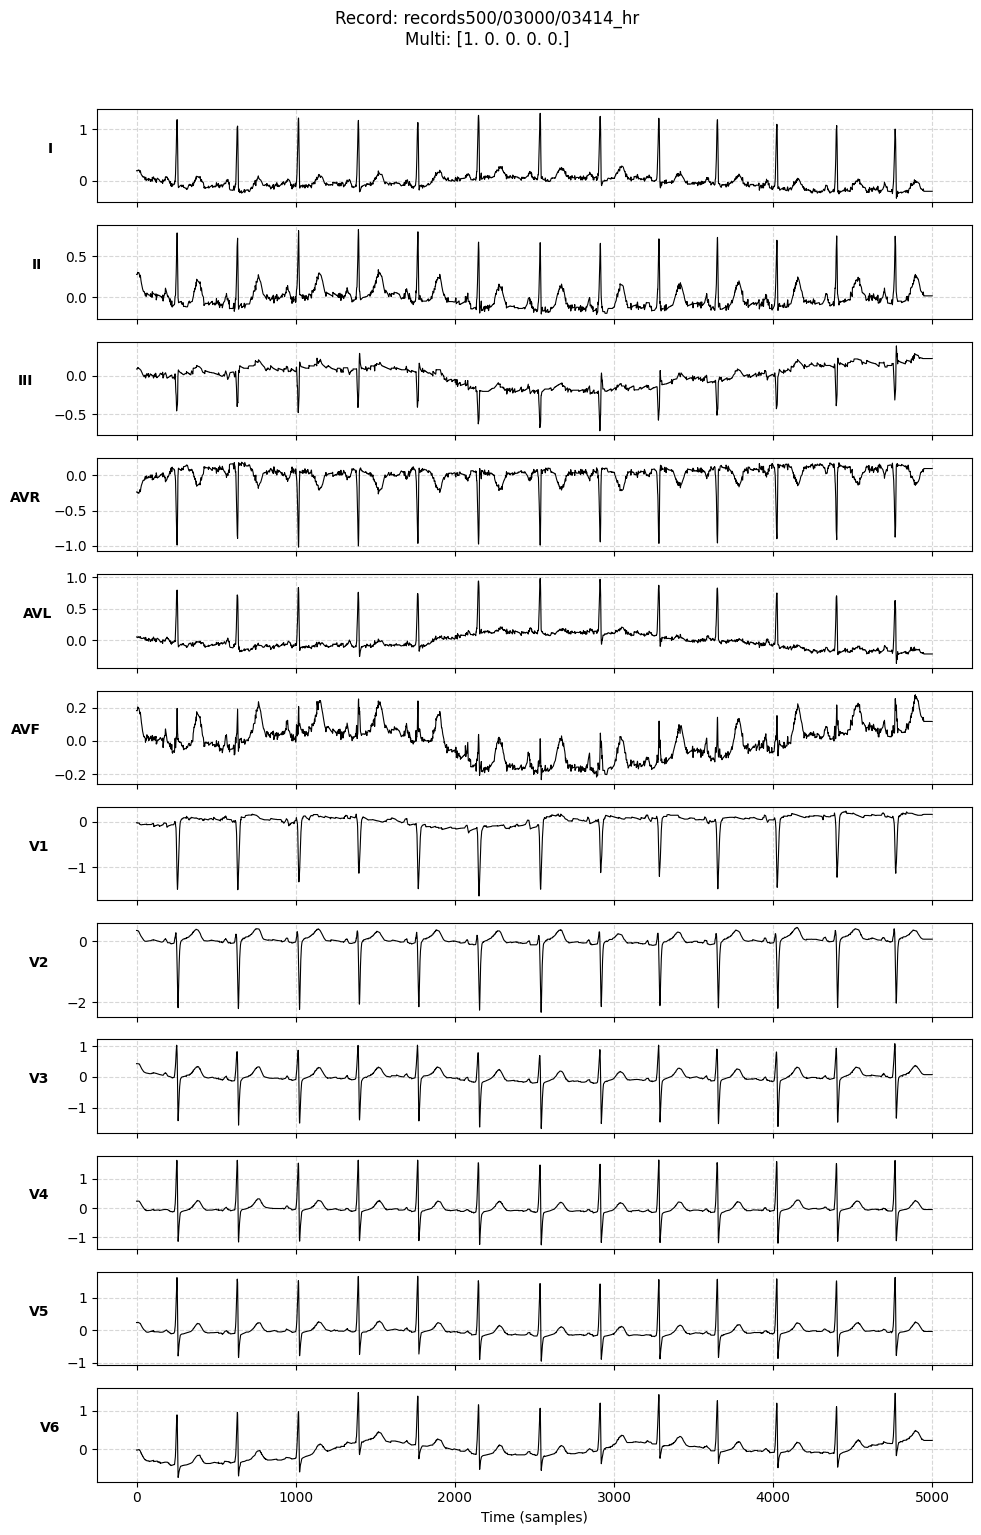

In [5]:
def load_signal_single(filename, base_path=DATASET_PATH):
    try:
        path = os.path.join(base_path, filename)
        signal, _ = wfdb.rdsamp(path)
        return signal.astype(np.float32)
    except:
        return None

def smoke_test(df, sample_rate=SAMPLE_RATE, count=1):
    print(f"Showing first {count} records (12-Lead view)...")

    lead_names = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    for row in df.itertuples():
        file = "filename_lr" if sample_rate == 100 else "filename_hr"
        sig = load_signal_single(getattr(row, file))
        if sig is None:
            continue

        # Ensure length
        sig = ensure_len(sig, sample_rate * 10)

        # Plot all 12 leads stacked
        fig, axes = plt.subplots(12, 1, figsize=(10, 15), sharex=True)

        for i in range(12):
            ax = axes[i]
            ax.plot(sig[:, i], color='black', linewidth=0.8)
            ax.set_ylabel(lead_names[i], rotation=0, labelpad=20, fontsize=10, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.5)
            if i < 11:
                ax.tick_params(labelbottom=False)

        plt.suptitle(f"Record: {getattr(row, file)}\nMulti: {row.label_vector}", y=1.02)
        plt.xlabel("Time (samples)")
        plt.tight_layout()
        plt.show()

        count -= 1
        if count == 0:
            return

smoke_test(ptb_df)

## Build and Split Dataset

In [6]:
def build_dataset(df, sample_rate=SAMPLE_RATE):
    X, y, folds = [], [], []
    file = "filename_lr" if sample_rate == 100 else "filename_hr"

    for row in tqdm(df.itertuples(), total=len(df), desc=f"Loading {sample_rate}Hz ECGs"):
        sig = load_signal_single(getattr(row, file)) 
        if sig is None: continue
            
        # Apply Clinical Bandpass Filter
        sig = apply_bandpass_filter(sig, fs=float(sample_rate))
        
        # Standardize length to 10 seconds (100 * 10 or 500 * 10)
        sig = ensure_len(sig, sample_rate * 10) 

        X.append(sig)
        y.append(row.label_vector)
        folds.append(row.strat_fold)

    # Stack to create 3D Array: (records, samples, 12)
    X = np.stack(X)
    y = np.stack(y)
    folds = np.array(folds)
    
    return X, y, folds

# Build
X, y, folds = build_dataset(ptb_df)

# Normalization
X = normalize_dataset(X)

# Split (1-8: Train, 9: Val, 10: Test)
train_idx = np.where(folds <= 8)[0]
val_idx   = np.where(folds == 9)[0]
test_idx  = np.where(folds == 10)[0]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# Display Shapes 
print("\n--- Dataset Description ---")
print(f"Total Records: {len(X)}")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape} | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")

Loading 500Hz ECGs: 100%|██████████| 10000/10000 [01:10<00:00, 141.88it/s]



--- Dataset Description ---
Total Records: 10000
X_train shape: (7978, 5000, 12) | y_train shape: (7978, 5)
X_val shape:   (1027, 5000, 12) | y_val shape:   (1027, 5)
X_test shape:  (995, 5000, 12)  | y_test shape:  (995, 5)


## Model Block Defination and Universal Evaluator

In [7]:
def convolutional_block(x, filters, kernel_size, padding='same', activation='relu'): 
    x = Conv1D(filters, kernel_size, padding=padding)(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    
    return x

def bottleneck_block(x, filters, kernel_size, padding='same', activation='relu'): 
    x = Conv1D(filters, kernel_size, padding=padding)(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    
    return x
    
def dense_block(x, filters, kernel_size, padding='same', activation='swish'):
    # Save the Features
    shortcut = x
    
    # Feature Extraction Path
    x = Conv1D(filters, kernel_size, padding=padding)(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    
    x = Conv1D(filters, kernel_size, padding=padding)(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    
    # Dense Connection: Concatenate input with extracted features
    x = Concatenate()([shortcut, x]) 
    x = Activation(activation)(x)
    
    return x

def residual_block(x, filters, kernel_size, padding='same', activation='swish'):
    # Save the Features
    shortcut = x
    
    # Feature Extraction Path
    x = Conv1D(filters, kernel_size, padding=padding)(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    
    x = SpatialDropout1D(0.1)(x)
    
    x = Conv1D(filters, kernel_size, padding=padding)(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    
    # Dimension Matching to Current x
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Residual Connection: Add input with extracted features
    x = Add()([x, shortcut]) 
    x = Activation(activation)(x)
    
    return x

def evaluate_model(model_name, y_true_bin, y_pred_prob, thresholds, class_names=CLASS_NAMES): 
    # Apply threshold to get binary predictions for F1 and Confusion Matrix
    y_pred_bin = np.zeros_like(y_pred_prob)
    for i in range(len(class_names)):
        y_pred_bin[:, i] = (y_pred_prob[:, i] >= thresholds[i]).astype(int)

    # --- Metrics Summary Table ---
    metrics_data = []
    for i in range(len(class_names)):
        c_auc = roc_auc_score(y_true_bin[:, i], y_pred_prob[:, i])
        c_f1 = f1_score(y_true_bin[:, i], y_pred_bin[:, i])
        metrics_data.append({"Class": class_names[i], "AUC-ROC": c_auc, "F1-Score": c_f1})
    
    # Calculate Macro Averages
    macro_auc = roc_auc_score(y_true_bin, y_pred_prob, average='macro')
    macro_f1 = f1_score(y_true_bin, y_pred_bin, average='macro')
    
    df_metrics = pd.DataFrame(metrics_data)
    summary_row = pd.DataFrame([{"Class": "MACRO-AVG", "AUC-ROC": macro_auc, "F1-Score": macro_f1}])
    df_metrics = pd.concat([df_metrics, summary_row], ignore_index=True)
    
    print(f"\n{'='*60}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*60}")
    print(df_metrics.to_string(index=False))
    print("\n")

    # --- Confusion Matrices ---
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    for i in range(len(class_names)):
        cm = confusion_matrix(y_true_bin[:, i], y_pred_bin[:, i])
        sns.heatmap(
            cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False,
            square=True, annot_kws={"size": 20, "weight": "bold"}
        )
        axes[i].tick_params(axis='both', which='major', labelsize=16)
        axes[i].set_title(f'CM: {class_names[i]}', fontsize=20, fontweight='bold')
        axes[i].set_xlabel('Predicted', fontsize=18)
        axes[i].set_ylabel('Actual', fontsize=18)
        
    plt.tight_layout()
    plt.show()

    # --- ROC and PR Curves ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Calculate and plot per-class AUC-ROC
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    for i in range(len(class_names)):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        axes[0].plot(fpr_dict[i], tpr_dict[i], lw=1.5, label=f'ROC {class_names[i]}')

    # Calculate Macro-average ROC (mean of all FPR/TPR)
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= len(class_names)
    
    axes[0].plot(all_fpr, mean_tpr, label=f'MACRO-AVG', color='black', linestyle=':', linewidth=4)
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curves', fontsize=15)
    axes[0].legend(loc="lower right", fontsize=12)
    axes[0].grid(alpha=0.3)

    # Calculate and plot per-class AUC-PR
    precision_dict, recall_dict, ap_dict = {}, {}, {}
    for i in range(len(class_names)):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(y_true_bin[:, i], y_pred_prob[:, i])
        axes[1].plot(recall_dict[i], precision_dict[i], lw=1.5, label=f'PR {class_names[i]}')

    axes[1].set_xlabel('Recall', fontsize=12)
    axes[1].set_ylabel('Precision', fontsize=12)
    axes[1].set_title(f'PR Curves', fontsize=15)
    axes[1].legend(loc="upper right", fontsize=12)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## DenseNet Model Building and Training

In [8]:
# --- Configuration ---
INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
EPOCHS = 50
BATCH_SIZE = 16

# --- Define the DenseNet Model ---
def build_dense_net(input_shape=INPUT_SHAPE, class_num=CLASS_NUM):
    # Input Layer
    inputs = Input(shape=input_shape)
    
    # Block 0: Stem Layer
    x = convolutional_block(inputs, filters=36, kernel_size=32)
    x = MaxPooling1D(pool_size=2)(x) 

    # Block 1: Dense Layer
    x = dense_block(x, filters=72, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 2: Dense Layer
    x = dense_block(x, filters=144, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 3: Dense Layer
    x = dense_block(x, filters=216, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 4: Dense Layer
    x = dense_block(x, filters=288, kernel_size=11) 
    x = MaxPooling1D(pool_size=2)(x)  
    
    # Block 5: GAP and Reshpae Layer
    x = dense_block(x, filters=288, kernel_size=11) 
    x = GlobalAveragePooling1D()(x)
    x = Reshape((1, x.shape[-1]))(x)
    
    # Block 6: Bottleneck Layer
    x = bottleneck_block(x, filters=72, kernel_size=1)
    
    # Output Layer
    outputs = bottleneck_block(x, filters=class_num, kernel_size=1, activation='sigmoid')
    outputs = Flatten()(outputs)
    
    model = Model(inputs=inputs, outputs=outputs, name="One_Branch_DenseNet")
    return model

# --- Compile and Train the Model ---
dense_net = build_dense_net()

dense_net.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy',
    metrics=[AUC(name='auc', multi_label=True)]
)

dense_net.summary()

callbacks_dense_net = [
    EarlyStopping(
        monitor='val_auc', mode='max', patience=8, 
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max', factor=0.5, 
        patience=5, min_lr=0.00001, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "DenseNet.keras"), 
        monitor='val_auc', mode='max', save_best_only=True, verbose=1
    )
]

history_dense_net = dense_net.fit(
    X_train, y_train,        # Folds 1-8
    validation_data=(X_val, y_val), # Fold 9
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_dense_net,
    verbose=1
)

I0000 00:00:1778605417.558651     711 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "One_Branch_DenseNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 5000, 36)  │     13,860 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 5000, 36)  │        144 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 5000, 36)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 2500, 36)  │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2500, 72)  │     28,584 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 72)  │        288 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2500, 72)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2500, 72)  │     57,096 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 72)  │        288 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 2500, 72)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2500, 108) │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 2500, 108) │          0 │ concatenate[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 1250, 108) │          0 │ activation_3[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1250, 144) │    171,216 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1250, 144) │        576 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 1250, 144) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1250, 144) │    228,240 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,399,069 (28.23 MB)

 Trainable params: 7,394,811 (28.21 MB)

...

Epoch 1/50


I0000 00:00:1778605432.045295     783 service.cc:152] XLA service 0x7a8e6c001df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778605432.045346     783 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778605433.632753     783 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/499 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - auc: 0.4653 - loss: 0.8608   

I0000 00:00:1778605443.933997     783 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - auc: 0.8024 - loss: 0.5716
Epoch 1: val_auc improved from -inf to 0.86773, saving model to /kaggle/working/DenseNet.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 68s 95ms/step - auc: 0.8024 - loss: 0.5715 - val_auc: 0.8677 - val_loss: 0.4544 - learning_rate: 0.0010
Epoch 2/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - auc: 0.8716 - loss: 0.4308
Epoch 2: val_auc improved from 0.86773 to 0.87488, saving model to /kaggle/working/DenseNet.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - auc: 0.8716 - loss: 0.4308 - val_auc: 0.8749 - val_loss: 0.3954 - learning_rate: 0.0010
Epoch 3/50
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - auc: 0.8844 - loss: 0.3757
Epoch 3: val_auc did not improve from 0.87488
499/499 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - auc: 0.8844 - loss: 0.3757 - val_auc: 0.8741 - val_loss: 0.3968 - learning_rate: 0.0010
Epoch 4/50
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - auc: 0.8931 - loss: 0.3443
Epoch 4: val_auc improved from 0.87488 to 0.8

## DenseNet Model Evaluation

Generating Probabilities...

Tuning threshold on Validation Set...
Class: NORM   | Best T: 0.618 | F1: 0.8394
Class: MI     | Best T: 0.239 | F1: 0.7132
Class: STTC   | Best T: 0.308 | F1: 0.7114
Class: CD     | Best T: 0.315 | F1: 0.7540
Class: HYP    | Best T: 0.224 | F1: 0.4870

Performing Final Evaluation on Test Set (Fold 10)...

EVALUATION: Dense Net
    Class  AUC-ROC  F1-Score
     NORM 0.940341  0.868369
       MI 0.904144  0.706564
     STTC 0.917080  0.726577
       CD 0.911595  0.742004
      HYP 0.829235  0.511013
MACRO-AVG 0.900479  0.710906




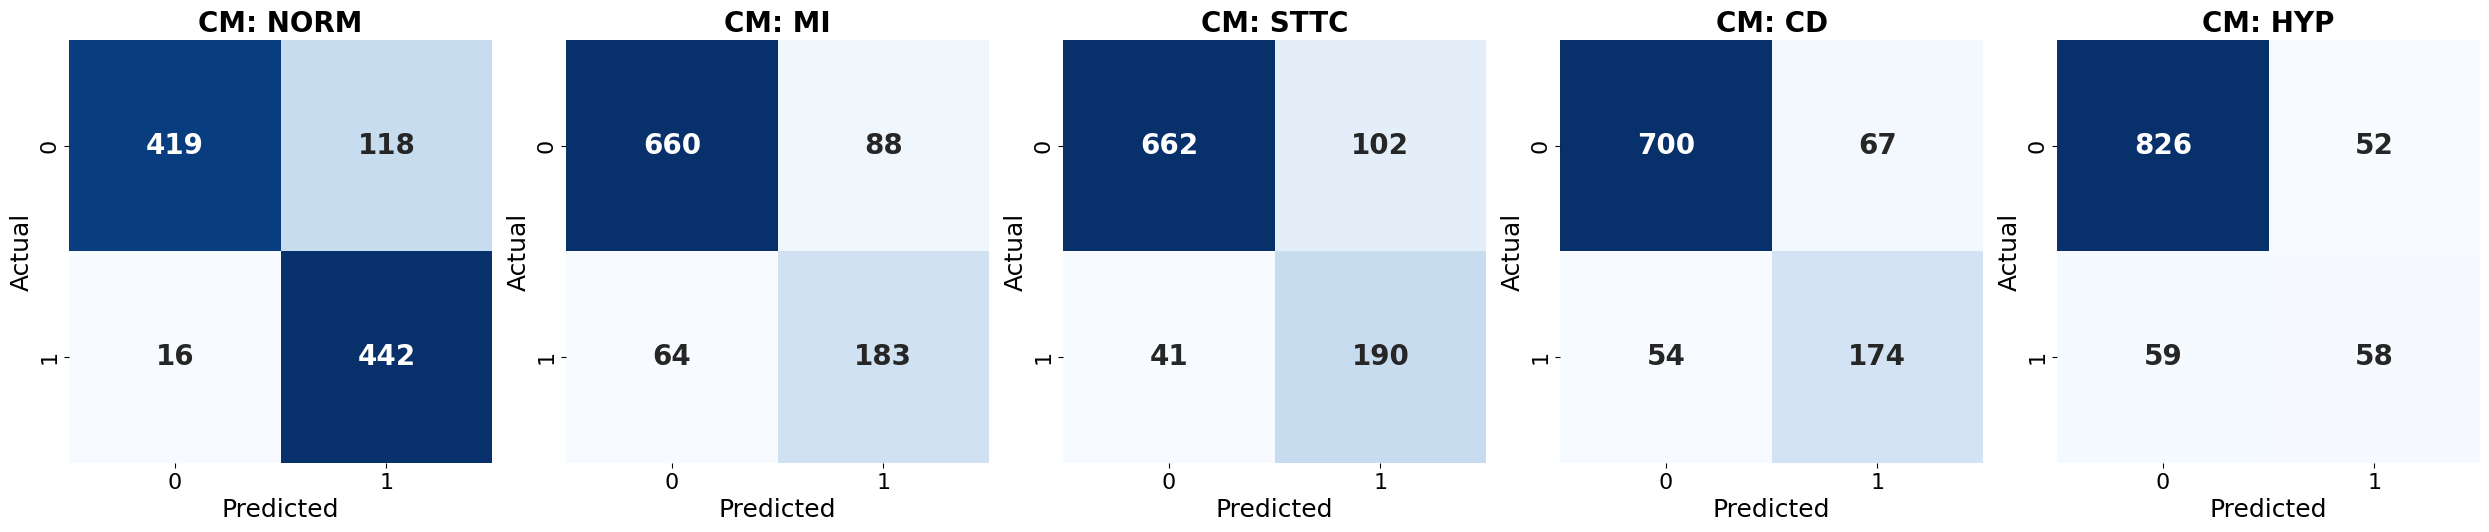

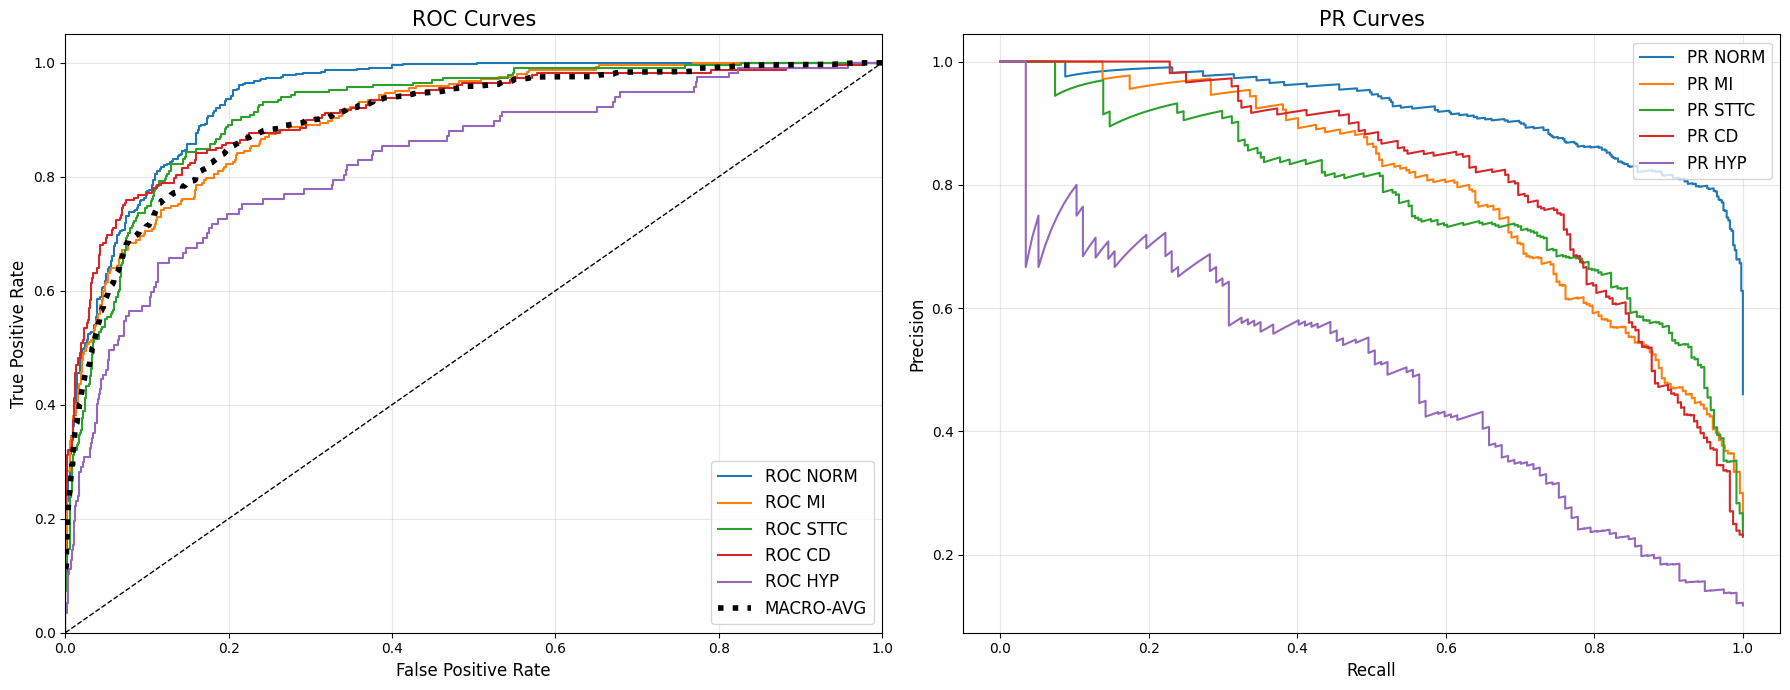

In [9]:
# Predict on Validation and Test Sets
print("Generating Probabilities...")
y_val_prob = dense_net.predict(X_val, verbose=0)
y_test_prob = dense_net.predict(X_test, verbose=0)

# Find Optimal Threshold on Validation Set (Fold 9)
print("\nTuning threshold on Validation Set...")
opt_thresholds = find_optimal_thresholds(y_val, y_val_prob)

# Evaluate on Test Set (Fold 10) using tuned threshold
print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
res_dense_net = evaluate_model("Dense Net", y_test, y_test_prob, opt_thresholds)

## ResNet Model Building and Training

In [10]:
# --- Configuration ---
INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
EPOCHS = 50
BATCH_SIZE = 16

# --- Define the ResNet Model ---
def build_res_net(input_shape=INPUT_SHAPE, class_num=CLASS_NUM):
    # Input Layer
    inputs = Input(shape=input_shape)
    
    # Block 0: Stem Layer
    x = convolutional_block(inputs, filters=36, kernel_size=32)
    x = MaxPooling1D(pool_size=2)(x) 

    # Block 1: Residual Layer
    x = residual_block(x, filters=72, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 2: Residual Layer
    x = residual_block(x, filters=144, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 3: Residual Layer
    x = residual_block(x, filters=216, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 4: Residual Layer
    x = residual_block(x, filters=288, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 5: GAP and Reshpae Layer
    x = residual_block(x, filters=288, kernel_size=7)
    x = GlobalAveragePooling1D()(x)
    x = Reshape((1, x.shape[-1]))(x)
    
    # Block 6: Bottleneck Layer
    x = bottleneck_block(x, filters=72, kernel_size=1)
    
    # Output Layer
    outputs = bottleneck_block(x, filters=class_num, kernel_size=1, activation='sigmoid')
    outputs = Flatten()(outputs)
    
    model = Model(inputs=inputs, outputs=outputs, name="One_Branch_ResNet")
    return model

# --- Compile and Train the Model ---
res_net = build_res_net()

res_net.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy',
    metrics=[AUC(name='auc', multi_label=True)]
)

res_net.summary()

callbacks_res_net = [
    EarlyStopping(
        monitor='val_auc', mode='max', patience=8, 
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max', factor=0.5, 
        patience=5, min_lr=0.00001, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "ResNet.keras"), 
        monitor='val_auc', mode='max', save_best_only=True, verbose=1
    ) 
]

history_res_net = res_net.fit(
    X_train, y_train,        # Folds 1-8
    validation_data=(X_val, y_val), # Fold 9
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_res_net,
    verbose=1
)

Model: "One_Branch_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 5000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 5000, 36)  │     13,860 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 5000, 36)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 2500, 36)  │          0 │ activation_18[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 2500, 72)  │     28,584 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 72)  │        288 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 2500, 72)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 2500, 72)  │          0 │ activation_19[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 2500, 72)  │     57,096 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 72)  │        288 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 2500, 72)  │      2,664 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 2500, 72)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 72)  │        288 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2500, 72)  │          0 │ activation_20[0]… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 2500, 72)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 1250, 72)  │          0 │ activation_21[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 1250, 144) │    114,192 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,196,365 (16.01 MB)

 Trainable params: 4,190,667 (15.99 MB)

 Non-trainable params: 5,698 (22.26 KB)

Epoch 1/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - auc: 0.8135 - loss: 0.5594
Epoch 1: val_auc improved from -inf to 0.86229, saving model to /kaggle/working/ResNet.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step - auc: 0.8136 - loss: 0.5593 - val_auc: 0.8623 - val_loss: 0.4524 - learning_rate: 0.0010
Epoch 2/50
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - auc: 0.8731 - loss: 0.4293
Epoch 2: val_auc did not improve from 0.86229
499/499 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - auc: 0.8731 - loss: 0.4292 - val_auc: 0.8608 - val_loss: 0.4093 - learning_rate: 0.0010
Epoch 3/50
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - auc: 0.8850 - loss: 0.3751
Epoch 3: val_auc improved from 0.86229 to 0.88230, saving model to /kaggle/working/ResNet.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - auc: 0.8850 - loss: 0.3751 - val_auc: 0.8823 - val_loss: 0.3713 - learning_rate: 0.0010
Epoch 4/50
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - auc: 0.8910 - loss: 0.3451
Epoch 4: val_auc improved from 0.88230

## ResNet Model Evaluation

Generating Probabilities...

Tuning threshold on Validation Set...
Class: NORM   | Best T: 0.573 | F1: 0.8400
Class: MI     | Best T: 0.406 | F1: 0.7121
Class: STTC   | Best T: 0.186 | F1: 0.7191
Class: CD     | Best T: 0.323 | F1: 0.7672
Class: HYP    | Best T: 0.270 | F1: 0.4878

Performing Final Evaluation on Test Set (Fold 10)...

EVALUATION: Res Net
    Class  AUC-ROC  F1-Score
     NORM 0.942272  0.849020
       MI 0.901259  0.700201
     STTC 0.922690  0.721190
       CD 0.907340  0.715640
      HYP 0.793879  0.455696
MACRO-AVG 0.893488  0.688349




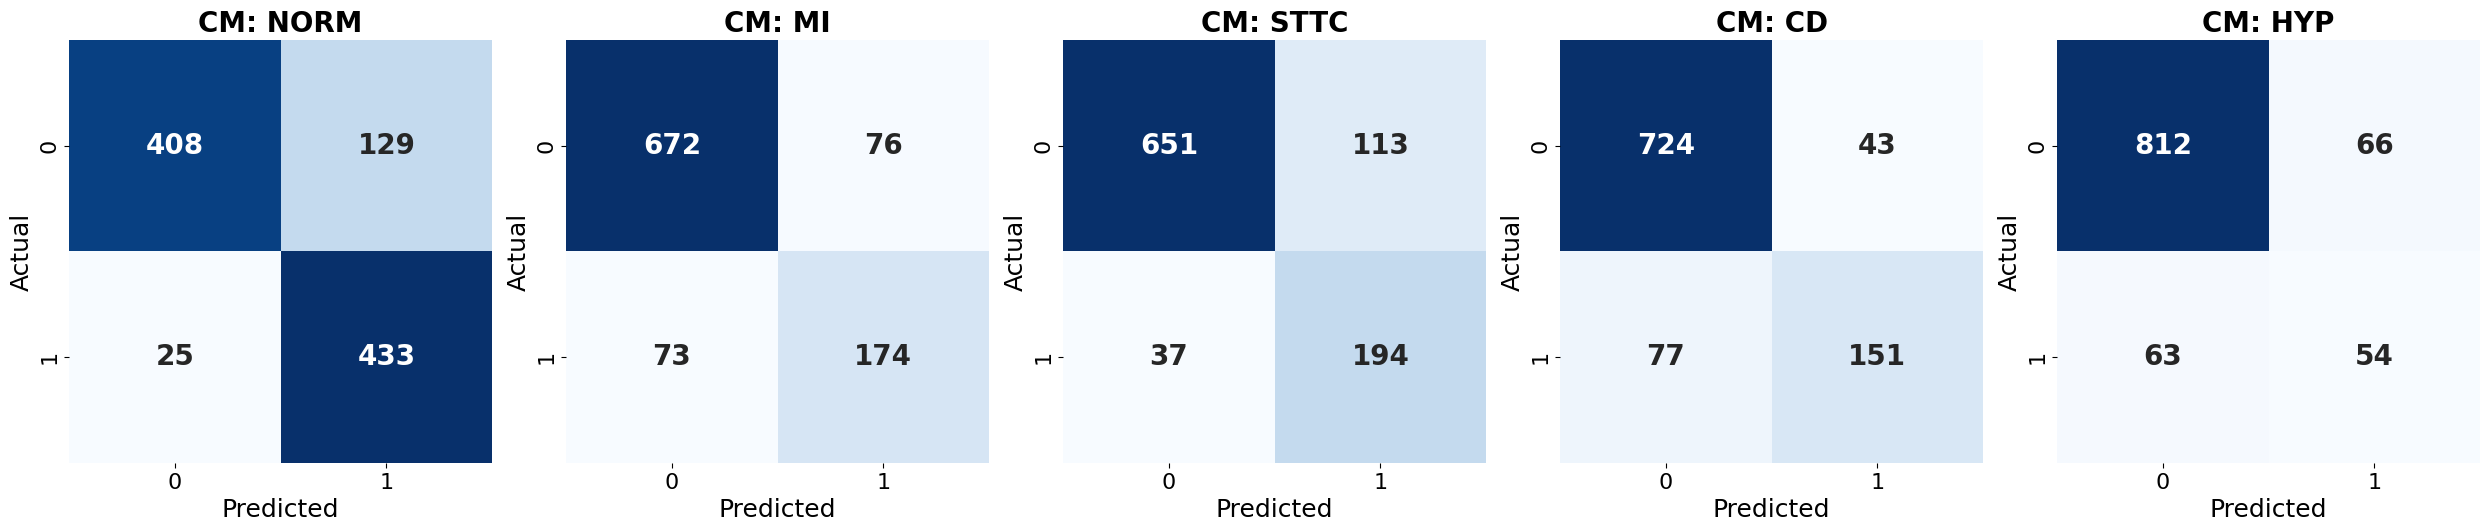

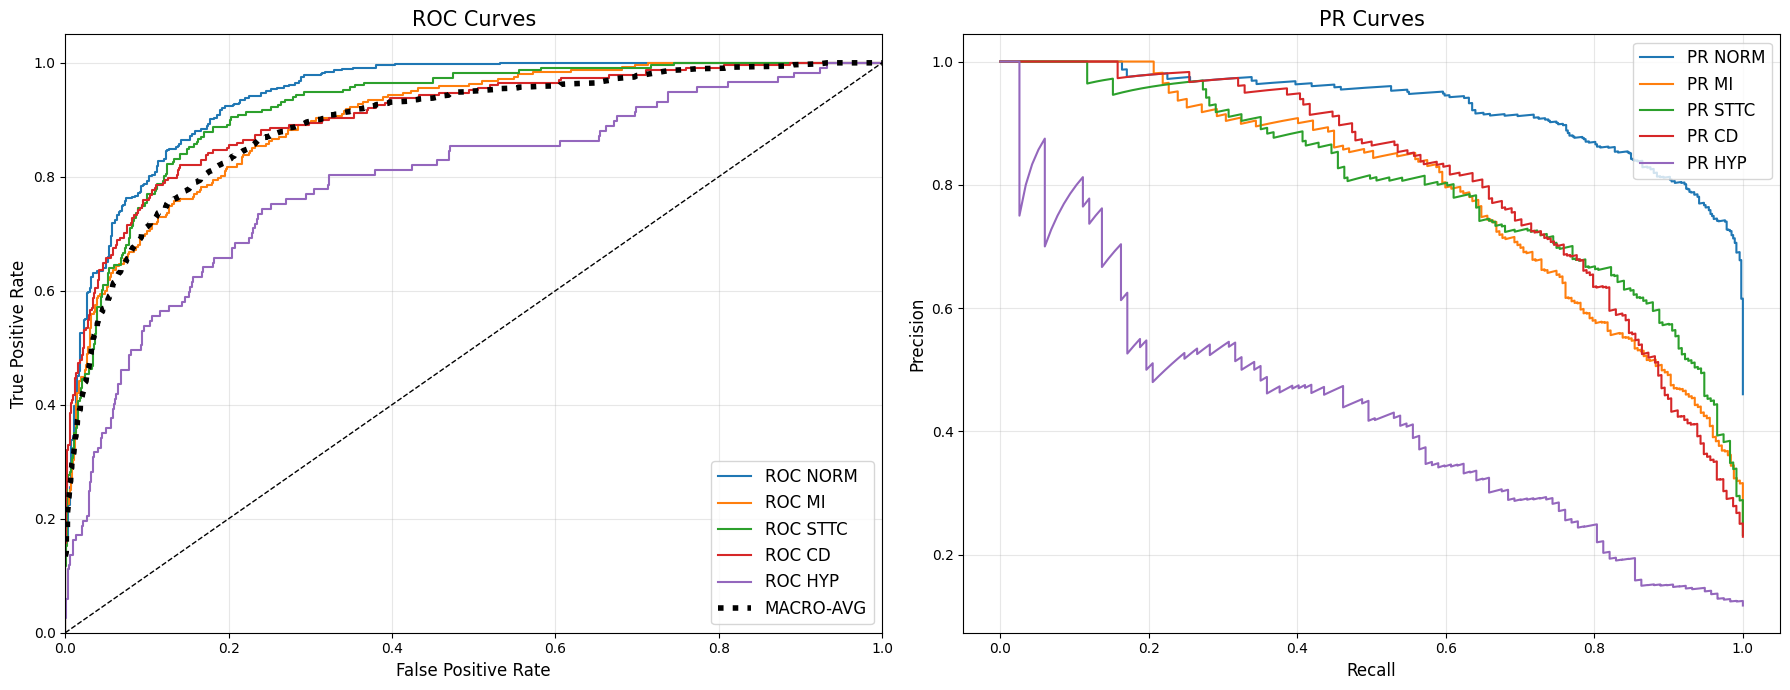

In [11]:
# Predict on Validation and Test Sets
print("Generating Probabilities...")
y_val_prob = res_net.predict(X_val, verbose=0)
y_test_prob = res_net.predict(X_test, verbose=0)

# Find Optimal Threshold on Validation Set (Fold 9)
print("\nTuning threshold on Validation Set...")
opt_thresholds = find_optimal_thresholds(y_val, y_val_prob)

# Evaluate on Test Set (Fold 10) using tuned threshold
print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
res_res_net = evaluate_model("Res Net", y_test, y_test_prob, opt_thresholds)

## AG-ResNet Model Building and Training

In [12]:
# --- Configuration ---
INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
EPOCHS = 50
BATCH_SIZE = 16

# --- Define the ResNet Model ---
def build_ag_res_net(input_shape=INPUT_SHAPE, class_num=CLASS_NUM):
    # Input Layer
    inputs = Input(shape=input_shape)

    # Branching into 5 Branch
    septal = Lambda(lambda x: tf.gather(x, [6, 7], axis=2), name="Septal")(inputs)
    anterior = Lambda(lambda x: tf.gather(x, [8, 9], axis=2), name="Anterior")(inputs)
    lateral = Lambda(lambda x: tf.gather(x, [0, 4, 10, 11], axis=2), name="Lateral")(inputs)
    inferior = Lambda(lambda x: tf.gather(x, [1, 2, 5], axis=2), name="Inferior")(inputs)
    posterior = Lambda(lambda x: tf.gather(x, [3], axis=2), name="Posterior")(inputs) 

    branches = []

    for branch in [septal, anterior, lateral, inferior, posterior]:
        # Block 0: Stem Layer
        x = convolutional_block(branch, filters=36, kernel_size=32)
        x = MaxPooling1D(pool_size=2)(x)

        # Block 1: Residual Layer
        x = residual_block(x, filters=72, kernel_size=11)
        x = MaxPooling1D(pool_size=2)(x) 
        
        # Block 2: Residual Layer
        x = residual_block(x, filters=144, kernel_size=11)
        x = MaxPooling1D(pool_size=2)(x) 

        branches.append(x)

    x = Concatenate()(branches)
    
    # Block 3: Residual Layer
    x = residual_block(x, filters=216, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 4: Residual Layer
    x = residual_block(x, filters=288, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 5: GAP and Reshpae Layer
    x = residual_block(x, filters=288, kernel_size=7)
    x = GlobalAveragePooling1D()(x)
    x = Reshape((1, x.shape[-1]))(x)
    
    # Block 6: Bottleneck Layer
    x = bottleneck_block(x, filters=72, kernel_size=1)
    
    # Output Layer
    outputs = bottleneck_block(x, filters=class_num, kernel_size=1, activation='sigmoid')
    outputs = Flatten()(outputs)
    
    model = Model(inputs=inputs, outputs=outputs, name="Five_Branch_AG_ResNet")
    return model

# --- Compile and Train the Model ---
ag_res_net = build_ag_res_net()

ag_res_net.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy',
    metrics=[AUC(name='auc', multi_label=True)]
)

ag_res_net.summary()

callbacks_ag_res_net = [
    EarlyStopping(
        monitor='val_auc', mode='max', patience=8, 
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max', factor=0.5, 
        patience=5, min_lr=0.00001, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "AG-ResNet.keras"), 
        monitor='val_auc', mode='max', save_best_only=True, verbose=1
    )
]

history_ag_res_net = ag_res_net.fit(
    X_train, y_train,        # Folds 1-8
    validation_data=(X_val, y_val), # Fold 9
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_ag_res_net,
    verbose=1
)

Model: "Five_Branch_AG_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 5000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Septal (Lambda)     │ (None, 5000, 2)   │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Anterior (Lambda)   │ (None, 5000, 2)   │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Lateral (Lambda)    │ (None, 5000, 4)   │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Inferior (Lambda)   │ (None, 5000, 3)   │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Posterior (Lambda)  │ (None, 5000, 1)   │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 5000, 36)  │      2,340 │ Septal[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_37 (Conv1D)  │ (None, 5000, 36)  │      2,340 │ Anterior[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_44 (Conv1D)  │ (None, 5000, 36)  │      4,644 │ Lateral[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_51 (Conv1D)  │ (None, 5000, 36)  │      3,492 │ Inferior[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_58 (Conv1D)  │ (None, 5000, 36)  │      1,188 │ Posterior[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_30[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_37[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_44[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_51[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_58[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 5000, 36)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_43       │ (None, 5000, 36)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_50       │ (None, 5000, 36)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_57       │ (None, 5000, 36)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 7,465,597 (28.48 MB)

 Trainable params: 7,454,427 (28.44 MB)

 Non-trainable params: 11,170 (43.63 KB)

Epoch 1/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - auc: 0.8177 - loss: 0.5575
Epoch 1: val_auc improved from -inf to 0.86144, saving model to /kaggle/working/AG-ResNet.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 158s 207ms/step - auc: 0.8178 - loss: 0.5574 - val_auc: 0.8614 - val_loss: 0.4910 - learning_rate: 0.0010
Epoch 2/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - auc: 0.8779 - loss: 0.4237
Epoch 2: val_auc improved from 0.86144 to 0.87891, saving model to /kaggle/working/AG-ResNet.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 70s 141ms/step - auc: 0.8779 - loss: 0.4236 - val_auc: 0.8789 - val_loss: 0.4255 - learning_rate: 0.0010
Epoch 3/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - auc: 0.8901 - loss: 0.3690
Epoch 3: val_auc improved from 0.87891 to 0.88392, saving model to /kaggle/working/AG-ResNet.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 71s 141ms/step - auc: 0.8901 - loss: 0.3690 - val_auc: 0.8839 - val_loss: 0.4001 - learning_rate: 0.0010
Epoch 4/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step 

## AG-ResNet Model Evaluation

Generating Probabilities...

Tuning threshold on Validation Set...
Class: NORM   | Best T: 0.467 | F1: 0.8330
Class: MI     | Best T: 0.482 | F1: 0.7259
Class: STTC   | Best T: 0.164 | F1: 0.7072
Class: CD     | Best T: 0.088 | F1: 0.8008
Class: HYP    | Best T: 0.353 | F1: 0.4783

Performing Final Evaluation on Test Set (Fold 10)...

EVALUATION: AG-ResNet
    Class  AUC-ROC  F1-Score
     NORM 0.940113  0.856031
       MI 0.911148  0.732919
     STTC 0.915182  0.720430
       CD 0.912378  0.721461
      HYP 0.827639  0.462222
MACRO-AVG 0.901292  0.698613




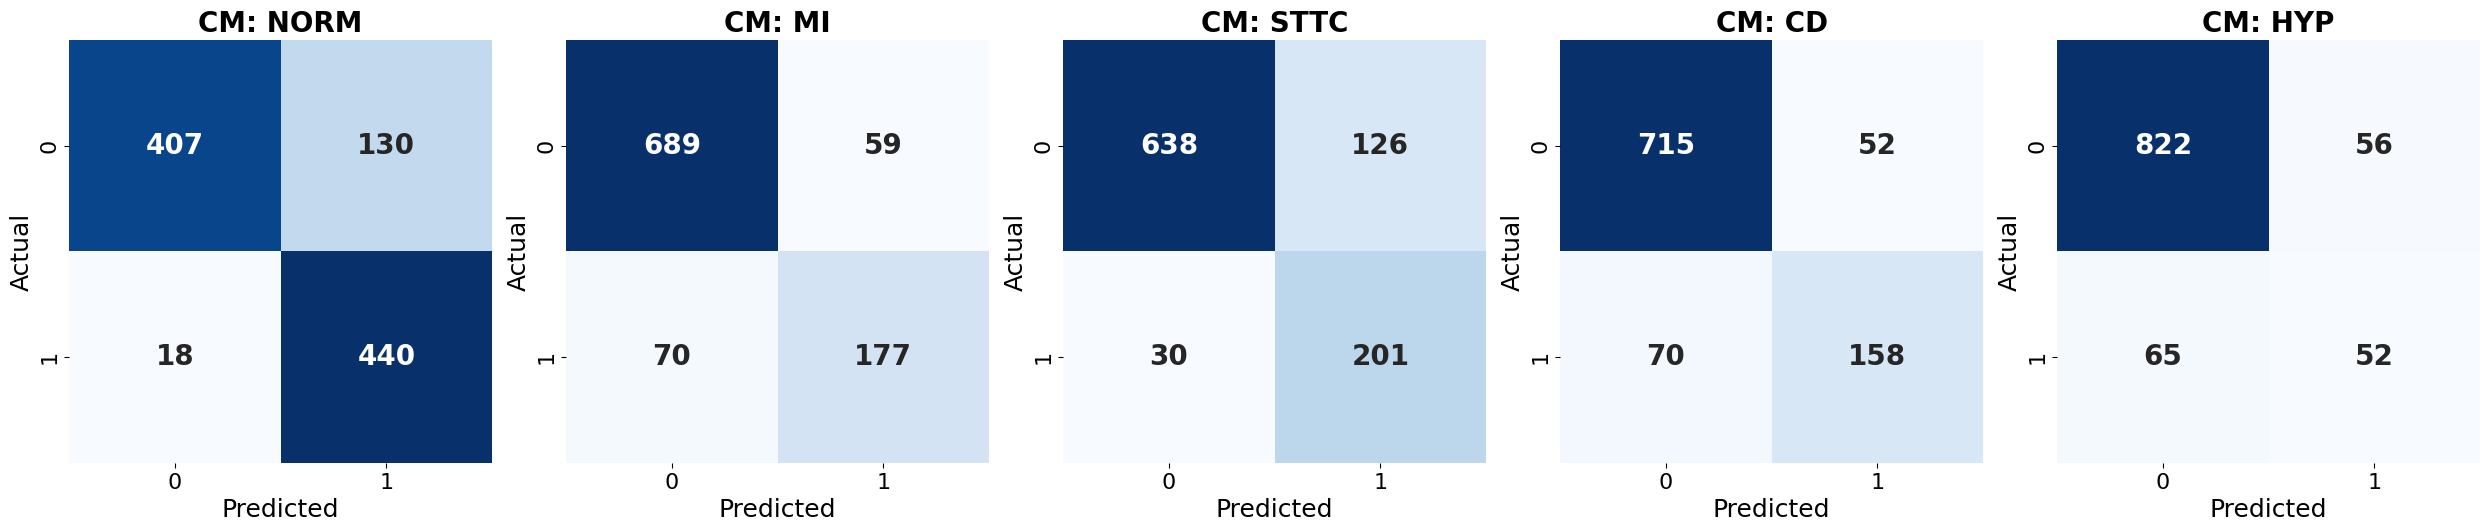

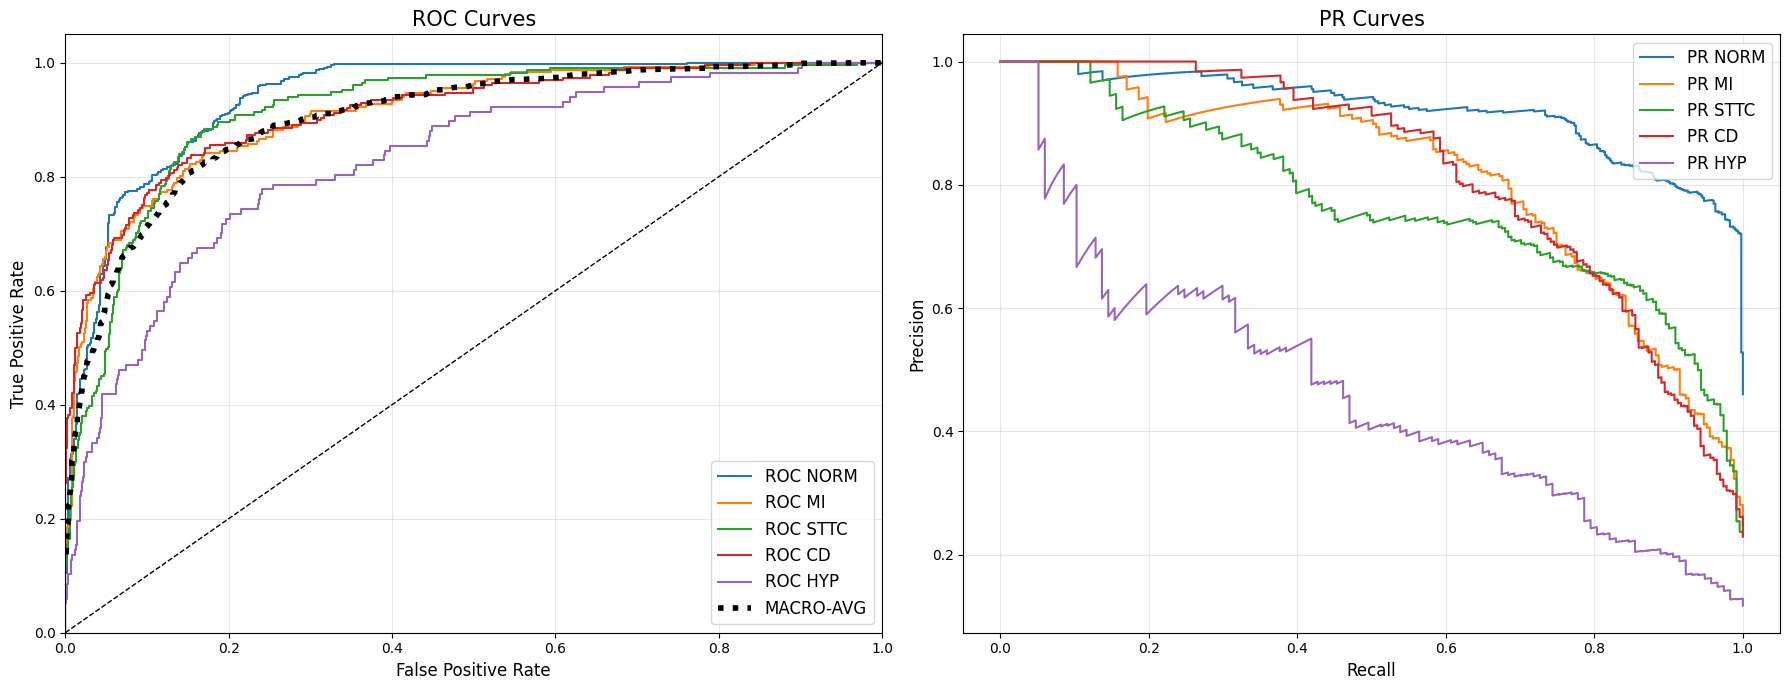

In [13]:
# Predict on Validation and Test Sets
print("Generating Probabilities...")
y_val_prob = ag_res_net.predict(X_val, verbose=0)
y_test_prob = ag_res_net.predict(X_test, verbose=0)

# Find Optimal Threshold on Validation Set (Fold 9)
print("\nTuning threshold on Validation Set...")
opt_thresholds = find_optimal_thresholds(y_val, y_val_prob)

# Evaluate on Test Set (Fold 10) using tuned threshold
print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
res_ag_res_net = evaluate_model("AG-ResNet", y_test, y_test_prob, opt_thresholds)

## AGGC-ResNet Model Building and Training

In [14]:
# --- Configuration ---
INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
EPOCHS = 50
BATCH_SIZE = 16

# --- Define the ResNet Model ---
def build_aggc_res_net(input_shape=INPUT_SHAPE, class_num=CLASS_NUM):
    # Input Layer
    inputs = Input(shape=input_shape)

    # Branching into 5 Branch
    septal = Lambda(lambda x: tf.gather(x, [6, 7], axis=2), name="Septal")(inputs)
    anterior = Lambda(lambda x: tf.gather(x, [8, 9], axis=2), name="Anterior")(inputs)
    lateral = Lambda(lambda x: tf.gather(x, [0, 4, 10, 11], axis=2), name="Lateral")(inputs)
    inferior = Lambda(lambda x: tf.gather(x, [1, 2, 5], axis=2), name="Inferior")(inputs)
    posterior = Lambda(lambda x: tf.gather(x, [3], axis=2), name="Posterior")(inputs) 

    branches = []

    for branch in [inputs, septal, anterior, lateral, inferior, posterior]:
        # Block 0: Stem Layer
        x = convolutional_block(branch, filters=36, kernel_size=32)
        x = MaxPooling1D(pool_size=2)(x)

        # Block 1: Residual Layer
        x = residual_block(x, filters=72, kernel_size=11)
        x = MaxPooling1D(pool_size=2)(x) 
        
        # Block 2: Residual Layer
        x = residual_block(x, filters=144, kernel_size=11)
        x = MaxPooling1D(pool_size=2)(x) 

        branches.append(x)

    x = Concatenate()(branches)
    
    # Block 3: Residual Layer
    x = residual_block(x, filters=216, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 4: Residual Layer
    x = residual_block(x, filters=288, kernel_size=11)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # Block 5: GAP and Reshpae Layer
    x = residual_block(x, filters=288, kernel_size=7)
    x = GlobalAveragePooling1D()(x)
    x = Reshape((1, x.shape[-1]))(x)
    
    # Block 6: Bottleneck Layer
    x = bottleneck_block(x, filters=72, kernel_size=1)
    
    # Output Layer
    outputs = bottleneck_block(x, filters=class_num, kernel_size=1, activation='sigmoid')
    outputs = Flatten()(outputs)
    
    model = Model(inputs=inputs, outputs=outputs, name="Six_Branch_AGGC_ResNet")
    return model

# --- Compile and Train the Model ---
aggc_res_net = build_aggc_res_net()

aggc_res_net.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy',
    metrics=[AUC(name='auc', multi_label=True)]
)

aggc_res_net.summary()

callbacks_aggc_res_net = [
    EarlyStopping(
        monitor='val_auc', mode='max', patience=8, 
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max', factor=0.5, 
        patience=5, min_lr=0.00001, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "AGGC-ResNet.keras"), 
        monitor='val_auc', mode='max', save_best_only=True, verbose=1
    )
]

history_aggc_res_net = aggc_res_net.fit(
    X_train, y_train,        # Folds 1-8
    validation_data=(X_val, y_val), # Fold 9
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_res_net,
    verbose=1
)

Model: "Six_Branch_AGGC_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 5000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Septal (Lambda)     │ (None, 5000, 2)   │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Anterior (Lambda)   │ (None, 5000, 2)   │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Lateral (Lambda)    │ (None, 5000, 4)   │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Inferior (Lambda)   │ (None, 5000, 3)   │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Posterior (Lambda)  │ (None, 5000, 1)   │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_75 (Conv1D)  │ (None, 5000, 36)  │     13,860 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_82 (Conv1D)  │ (None, 5000, 36)  │      2,340 │ Septal[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_89 (Conv1D)  │ (None, 5000, 36)  │      2,340 │ Anterior[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_96 (Conv1D)  │ (None, 5000, 36)  │      4,644 │ Lateral[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_103 (Conv1D) │ (None, 5000, 36)  │      3,492 │ Inferior[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_110 (Conv1D) │ (None, 5000, 36)  │      1,188 │ Posterior[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_75[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_82[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_89[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_96[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_103[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 36)  │        144 │ conv1d_110[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_82       │ (None, 5000, 36)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_89       │ (None, 5000, 36)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,296,729 (31.65 MB)

 Trainable params: 8,284,191 (31.60 MB)

 Non-trainable params: 12,538 (48.98 KB)

Epoch 1/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - auc: 0.8235 - loss: 0.5541
Epoch 1: val_auc did not improve from 0.88946
499/499 ━━━━━━━━━━━━━━━━━━━━ 180s 235ms/step - auc: 0.8236 - loss: 0.5540 - val_auc: 0.8652 - val_loss: 0.4360 - learning_rate: 0.0010
Epoch 2/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - auc: 0.8768 - loss: 0.4251
Epoch 2: val_auc did not improve from 0.88946
499/499 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - auc: 0.8768 - loss: 0.4250 - val_auc: 0.8781 - val_loss: 0.4296 - learning_rate: 0.0010
Epoch 3/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - auc: 0.8880 - loss: 0.3700
Epoch 3: val_auc did not improve from 0.88946
499/499 ━━━━━━━━━━━━━━━━━━━━ 81s 162ms/step - auc: 0.8880 - loss: 0.3700 - val_auc: 0.8841 - val_loss: 0.3927 - learning_rate: 0.0010
Epoch 4/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - auc: 0.8957 - loss: 0.3392
Epoch 4: val_auc did not improve from 0.88946
499/499 ━━━━━━━━━━━━━━━━━━━━ 81s 162ms/step - auc: 0.8957 - loss: 0.3392 - val_au

## AGGC-ResNet Model Evaluation

Generating Probabilities...

Tuning threshold on Validation Set...
Class: NORM   | Best T: 0.679 | F1: 0.8376
Class: MI     | Best T: 0.505 | F1: 0.7294
Class: STTC   | Best T: 0.171 | F1: 0.7141
Class: CD     | Best T: 0.255 | F1: 0.7747
Class: HYP    | Best T: 0.361 | F1: 0.4848

Performing Final Evaluation on Test Set (Fold 10)...

EVALUATION: AGGC-ResNet
    Class  AUC-ROC  F1-Score
     NORM 0.939434  0.851586
       MI 0.911922  0.717300
     STTC 0.922565  0.719424
       CD 0.891775  0.691765
      HYP 0.828330  0.455882
MACRO-AVG 0.898805  0.687192




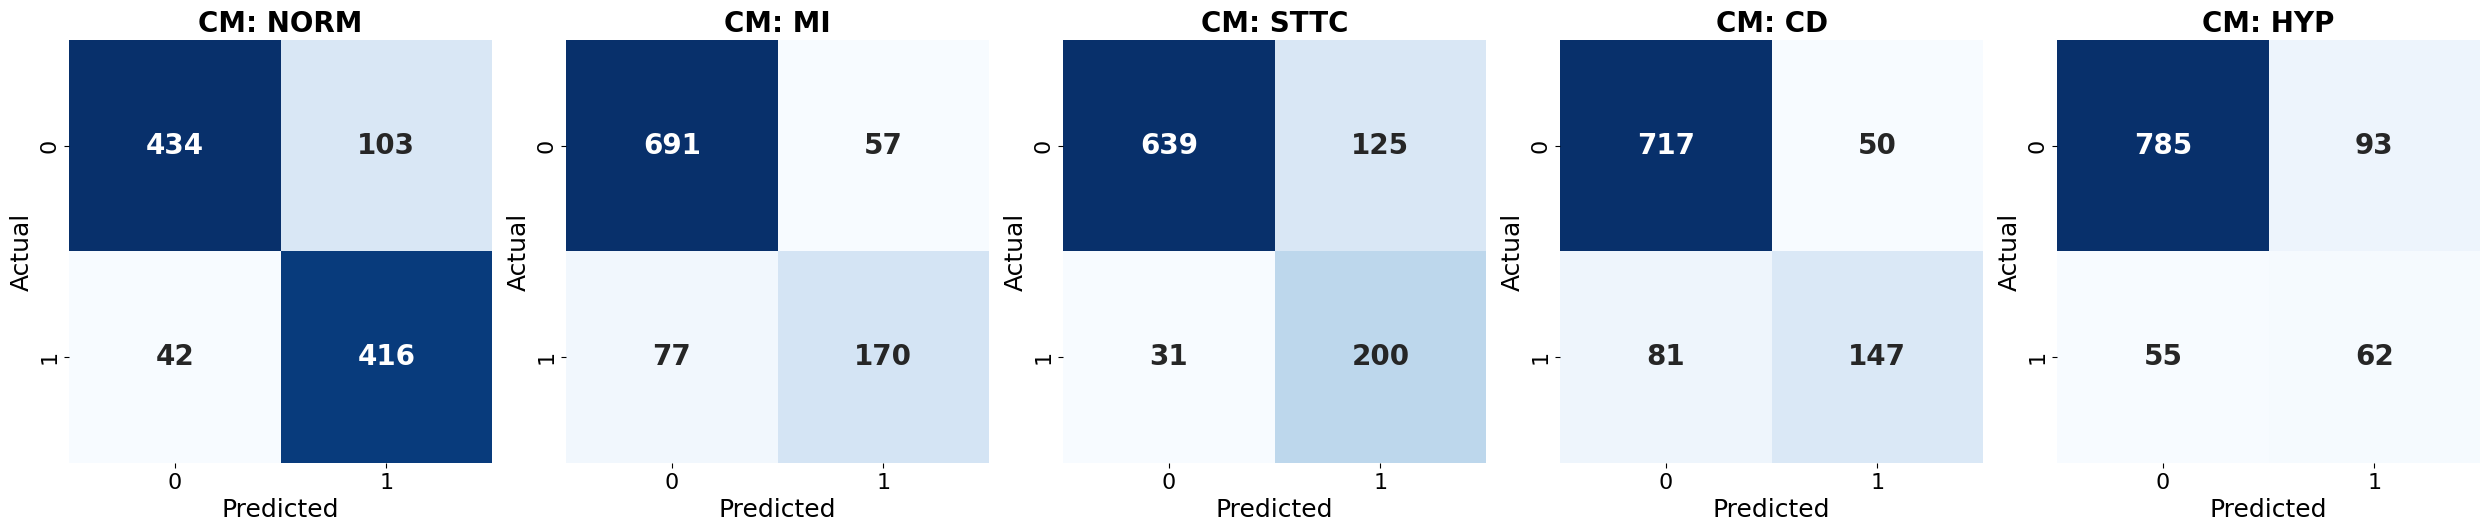

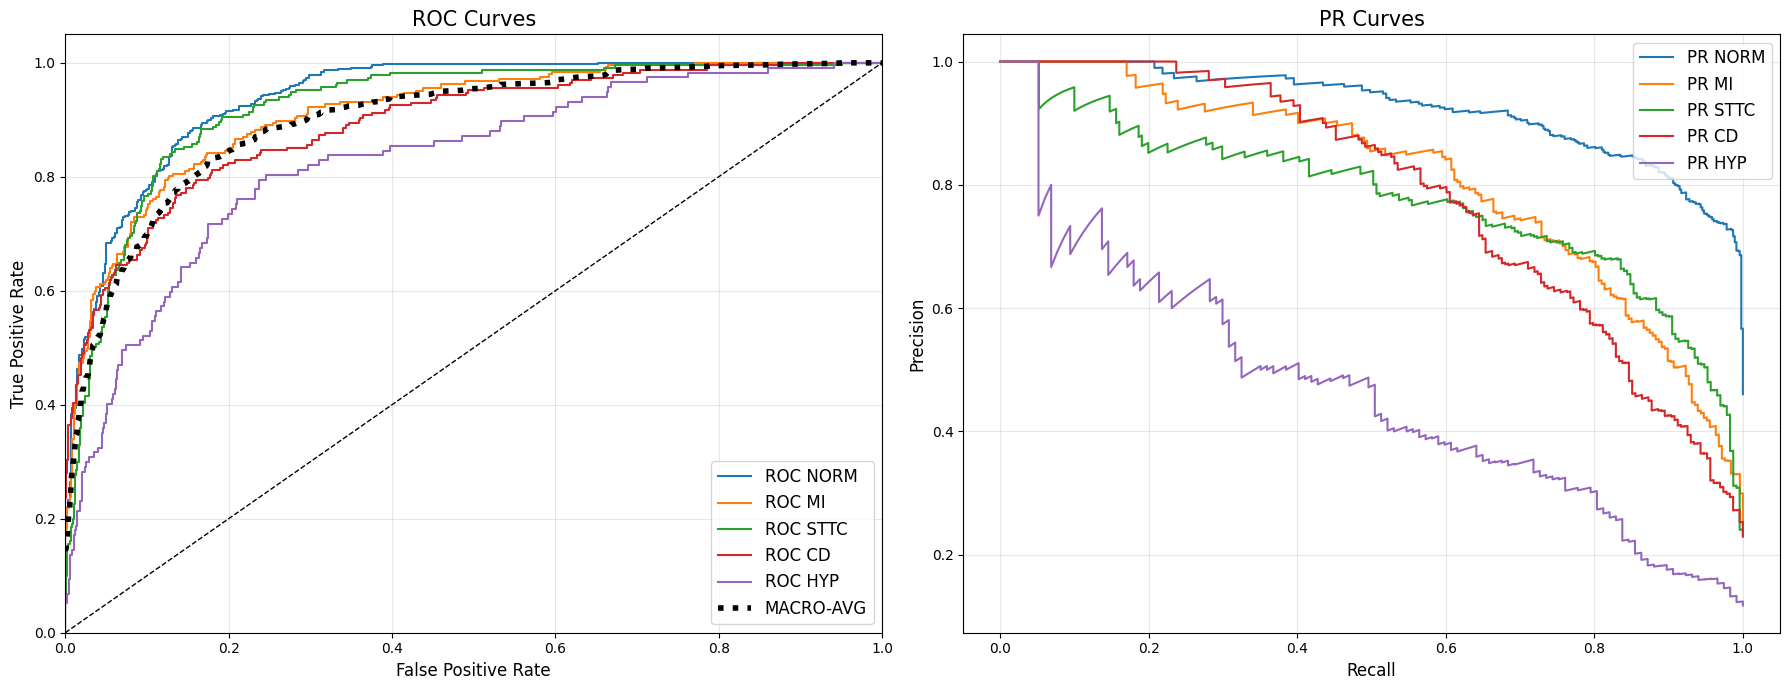

In [15]:
# Predict on Validation and Test Sets
print("Generating Probabilities...")
y_val_prob = aggc_res_net.predict(X_val, verbose=0)
y_test_prob = aggc_res_net.predict(X_test, verbose=0)

# Find Optimal Threshold on Validation Set (Fold 9)
print("\nTuning threshold on Validation Set...")
opt_thresholds = find_optimal_thresholds(y_val, y_val_prob)

# Evaluate on Test Set (Fold 10) using tuned threshold
print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
res_ag_res_net = evaluate_model("AGGC-ResNet", y_test, y_test_prob, opt_thresholds)

## CNN Model Building and Training (Binary Classification)

In [16]:
# # Configuration
# INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
# EPOCHS = 50
# BATCH_SIZE = 32

# # Define CNN Architecture
# def build_cnn(input_shape=INPUT_SHAPE):
#     """
#     Description: Constructs a 1D CNN with hierarchical blocks for multi-label 
#                  diagnostic classification using Sigmoid output and Macro-AUC.
#     Input: tuple (samples, leads)
#     Output: keras.Model
#     """
#     model = Sequential()
#     model.add(Input(shape=input_shape))                              # Shape: (32, 1000, 12)

#     # Block 1: Low-level features
#     model.add(Conv1D(filters=32, kernel_size=32, strides=2, padding='same'))    # Shape: (32, 500, 32)
#     model.add(BatchNormalization())
#     model.add(Activation('relu'))

#     # Block 2: Mid-level features
#     model.add(Conv1D(filters=64, kernel_size=15, strides=2, padding='same'))    # Shape: (32, 250, 64)
#     model.add(BatchNormalization())
#     model.add(Activation('relu'))

#     # Block 3: High-level features
#     model.add(Conv1D(filters=128, kernel_size=11, padding='same'))   # Shape: (32, 250, 128)
#     model.add(BatchNormalization())
#     model.add(Activation('relu'))

#     # Classifier Head
#     model.add(GlobalAveragePooling1D())                              # Shape: (32, 128)
#     model.add(Dense(128, activation='relu'))                         # Shape: (32, 128)
#     model.add(Dropout(0.5))
    
#     # Multi-label Output: 5 nodes with independent probabilities
#     model.add(Dense(NUM_CLASSES, activation='sigmoid'))              # Shape: (32, 5)

#     # Compile with Research Gold Standard (Macro-AUC)
#     model.compile(
#         optimizer=Adam(learning_rate=0.001), 
#         loss='binary_crossentropy', 
#         metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
#     )
#     return model

# # Build the model
# print(f"\n{'='*40}")
# print("BUILDING RESEARCH CNN")
# print(f"{'='*40}")
# cnn = build_cnn()
# cnn.summary()

# # Train using the Splits (Folds 1-8 for train, 9 for val)
# callbacks_cnn = [
#     EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
#     ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
# ]

# history_cnn = cnn.fit(
#     X_train, y_train,        # Folds 1-8
#     validation_data=(X_val, y_val), # Fold 9
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks_cnn,
#     verbose=1
# )

# # Save the model
# cnn.save(os.path.join(OUTPUT_DIR, 'cnn_model.keras'))

##  CNN Model Evaluation (Binary Classification)

In [17]:
# # Predict on Validation and Test Sets
# print("Generating Probabilities...")
# y_prob_val = cnn.predict(X_val, verbose=0)
# y_prob_test = cnn.predict(X_test, verbose=0)

# # Find Optimal Threshold on Validation Set (Fold 9)
# print("\nTuning threshold on Validation Set...")
# opt_threshold = find_optimal_thresholds(y_val, y_prob_val)

# # Evaluate on Test Set (Fold 10) using tuned threshold
# print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
# res_cnn = evaluate_model("1D CNN", y_test, y_prob_test, opt_threshold)

## AG-ResNET Model Building and Training (Binary Classification)

In [18]:
# # Configuration
# INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
# NUM_CLASSES = 5
# NUM_BLOCKS = 3
# FILTERS_START = 32

# LEARNING_RATE = 0.0005 
# BATCH_SIZE = 16
# EPOCHS = 50

# # Define Residual Block Architecture
# def residual_block(x, filters, kernel_size=10, stride=1):
#     """
#     Description: Implements a standard 1D Residual bottleneck with 'swish' activation and 
#                  spatial dropout; includes a 1x1 convolution shortcut if dimensions change.
#     Input: tensorflow.Tensor [time, channels], int, int, int
#     Output: tensorflow.Tensor [time/stride, filters]
#     """

#     shortcut = x

#     # Path A
#     x = Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
#     x = BatchNormalization()(x)
#     x = Activation('swish')(x)
#     x = SpatialDropout1D(0.2)(x)

#     x = Conv1D(filters, kernel_size, strides=1, padding='same')(x)
#     x = BatchNormalization()(x)

#     # Path B
#     if x.shape[-1] != shortcut.shape[-1] or stride != 1:
#         shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
#         shortcut = BatchNormalization()(shortcut)

#     x = Add()([x, shortcut])
#     x = Activation('swish')(x)
#     return x

# # Define AG ResNet Architecture
# def build_ag_resnet(input_shape=INPUT_SHAPE):
#     """
#     Description: Constructs the Anatomically Grouped ResNet by splitting 12 leads into 
#                  5 regional branches (Septal, Anterior, Lateral, Inferior, Posterior) before 
#                  fusing them for classification.
#     Note: samples = signal duration * frequency
#     Input: tuple (samples, leads)
#     Output: keras.src.models.model.Model
#     """
#     # --- BLOCK 1: INPUT & TRIAGE ---
#     input_layer = Input(shape=input_shape, name="ecg_input") # Shape: (16, 5000, 12)
 
#     septal = Lambda(lambda x: __import__('tensorflow').gather(x, [6, 7], axis=2), name="Septal")(input_layer)            # Shape: (16, 5000, 2)
#     anterior = Lambda(lambda x: __import__('tensorflow').gather(x, [8, 9], axis=2), name="Anterior")(input_layer)        # Shape: (16, 5000, 2)
#     lateral = Lambda(lambda x: __import__('tensorflow').gather(x, [0, 4, 10, 11], axis=2), name="Lateral")(input_layer)  # Shape: (16, 5000, 4)
#     inferior = Lambda(lambda x: __import__('tensorflow').gather(x, [1, 2, 5], axis=2), name="Inferior")(input_layer)     # Shape: (16, 5000, 3)
#     posterior = Lambda(lambda x: __import__('tensorflow').gather(x, [3], axis=2), name="Posterior")(input_layer)         # Shape: (16, 5000, 1)

#     # --- BLOCK 2: ENCODER ---
#     branches = []

#     for name, branch in zip(["Global", "Septal", "Anterior", "Lateral", "Inferior", "Posterior"],
#                             [input_layer, septal, anterior, lateral, inferior, posterior]):

#         # Initial Feature Extraction
#         x = Conv1D(FILTERS_START, 32, strides=2, padding='same', name=f"{name}_Conv1")(branch) # Shape: (16, 2500, 64)
#         x = BatchNormalization()(x)                                                                   # Shape: (16, 2500, 64)
#         x = Activation('swish')(x)                                                                    # Shape: (16, 2500, 64)

#         # Dynamic Residual Stacking
#         current_filters = FILTERS_START * 2
#         for i in range(NUM_BLOCKS):
#             x = residual_block(x, current_filters, stride=2) # Shape: (16, 1250, 128) -> (16, 625, 256) -> (16, 313, 512) -> (16, 157, 1024)
#             current_filters *= 2

#         x = GlobalAveragePooling1D(name=f"{name}_GlobalPool")(x) # Shape: (16, 1024)
#         branches.append(x)                                              # Shape: (16, 6, 1024)

#     # --- BLOCK 3: FUSION ---
#     m = Concatenate(name="Anatomical_Fusion")(branches) # Shape: (16, 6 * 1024)
#     m = Reshape((len(branches), -1))(m) 
#     m = Bidirectional(LSTM(128, return_sequences=False))(m)

#     # --- BLOCK 4: CLASSIFICATION HEAD ---
#     c = BatchNormalization()(m)                         # Shape: (16, 5120)
#     c = Dense(256, activation='swish')(c)                    # Shape: (16, 128)
#     c = Dropout(0.4)(c)                                      # Shape: (16, 128)
    
#     output_layer = Dense(NUM_CLASSES, activation='sigmoid', name="classification")(c)  # Shape: (16, 1)

#     # --- BLOCK 5: COMPILATION (Pure Classification) ---
#     model = Model(inputs=input_layer, outputs=output_layer, name="AG_ResNet")

#     # Added clipnorm=1.0 to prevent gradient explosions
#     model.compile(
#         optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0), 
#         loss="binary_crossentropy",
#         metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
#     )

#     return model

# # Build
# print(f"{'='*50}")
# print(f"AG-ResNet TRAINING (PURE CLASSIFIER)")
# print(f"Input: {INPUT_SHAPE}")
# print(f"Structure: {NUM_BLOCKS} Blocks | Start Filters: {FILTERS_START}")
# print(f"{'='*50}")

# ag_resnet = build_ag_resnet()

# # Train
# callbacks_ag_resnet = [
#     ReduceLROnPlateau(
#         monitor='val_auc', factor=0.2, 
#         patience=5, min_lr=1e-5, verbose=1
#     ),
#     EarlyStopping(
#         monitor='val_auc', mode='max', patience=12, 
#         restore_best_weights=True, verbose=1
#     ),
    # ModelCheckpoint(
    #     os.path.join(OUTPUT_DIR, "ag_resnet_multilabel.keras"), 
    #     monitor='val_auc', mode='max', save_best_only=True, verbose=1
    # )
# ]

# print("\nStarting Training...")
# history_ag_resnet = ag_resnet.fit(
#     x=X_train,              # Folds 1-8
#     y=y_train,              # Multi-label vectors [NORM, MI, STTC, CD, HYP]
#     validation_data=(X_val, y_val), # Fold 9
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks_ag_resnet,
#     verbose=1
# )

## AG-ResNET Model Evaluation (Binary Classification)

In [19]:
# # Predict on Validation and Test Sets
# print("Generating Probabilities...")
# y_prob_val = ag_resnet.predict(X_val, verbose=0)
# y_prob_test = ag_resnet.predict(X_test, verbose=0)

# # Find Optimal Threshold on Validation Set (Fold 9)
# print("\nTuning threshold on Validation Set...")
# opt_threshold = find_optimal_threshold(y_val, y_prob_val)

# # Evaluate on Test Set (Fold 10) using tuned threshold
# print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
# res_ag_resnet = evaluate_model("AG-ResNet", y_test, y_prob_test, opt_threshold)